# Unidade V - Aprendizagem Profunda (*Deep Learning*)
# Aula 02: *Perceptrons* e o modelo de Redes Neurais Profundas
# Roteiro
 * Conceitos básicos
 * Aprendizagem profunda (*Deep Learning*)
 * Configuração das redes neurais para aprendizagem profunda

## Conceitos básicos

Neurônios, dendritos e axônios são os componentes básicos do cérebro humano. Da mesma forma, o *perceptron* é a estrutura mais básica de uma rede neural artificial. A evolução das redes neurais ocorreu por meio de muitos trabalhos que partiam de premissas básicas, como:
 * neurônios podem se comunicar uns com os outros;
 * neurônios são fisicamente separados uns dos outros.

Diversos pesquisadores descreveram inicialmente uma arquitetura de redes neurais baseada na estrutura dos neurônios, que continha uma função de ativação de limiar binário, análoga às sentenças lógicas de primeira ordem. 

**Perceptrons multicamadas (*Multilayer Perceptrons* – MLP's)** podem ser vistos como generalizações de modelos lineares que realizam vários estágios de processamento para chegar a uma decisão. Lembre-se que a predição de um regressor linear é realizada por meio de uma equação como:

$ŷ = w[0] * x[0] + w[1] * x[1] + ... + w[p] * x[p] + b$

Nessa equação, $ŷ$ é a soma ponderada dos atributos de entrada $x[0]$ a $x[p]$, ponderada pelos **coeficientes (pesos)** $w[0]$ a $w[0]$, que são ajustados pelo modelo. Podemos visualizar isso graficamente na Figura a seguir.

In [1]:
import matplotlib.pyplot as plt

import mglearn
import numpy as np

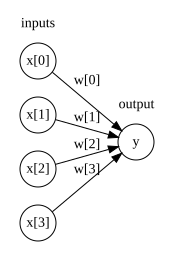

In [2]:
display(mglearn.plots.plot_logistic_regression_graph())

Na Figura acima, cada nó à esquerda representa um atributo de entrada, as linhas de conexão representam os coeficientes ajustados pelo modelo, e o nó à direita representa a saída, que é uma soma ponderada das entradas. 

Em um MLP, este processo de calcular as somas ponderadas é repetido várias vezes, primeiro computando os coeficientes das **camadas ocultas**, que representam uma etapa de processamento intermediária, que são novamente combinadas usando somas ponderadas para produzir o resultado final, como é representado na Figura a seguir.

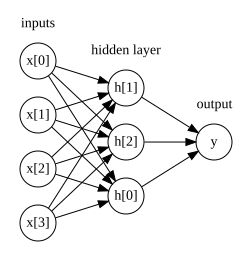

In [3]:
display(mglearn.plots.plot_single_hidden_layer_graph())

Este modelo tem muito mais coeficientes para ajustar: há um entre cada entrada e cada camada oculta, e um entre cada camada oculta e a saída. Calcular uma série de somas ponderadas é matematicamente igual a calcular apenas uma soma ponderada; portanto, para tornar este modelo realmente mais poderoso do que um modelo linear, precisamos de um truque extra. Depois de calcular uma soma ponderada para cada camada oculta, uma **função não linear** é aplicada ao resultado, geralmente a **função de não linearidade retificadora**, também conhecida como **unidade linear retificada (*rectified linear unit* ou *relu*)** ou a **função tangente hiperbólica** (tanh). 

O resultado dessa função é então usado na soma ponderada que calcula a saída $ŷ$. As duas funções são visualizadas na Figura a seguir. A *relu* exclui valores abaixo de zero, enquanto tanh "satura" para -1 para valores de entrada baixos e +1 para valores de entrada altos. Qualquer uma das funções não lineares permite que a rede neural aprenda funções muito mais complicadas do que um modelo linear poderia aprender.

Text(0, 0.5, 'relu(x), tanh(x)')

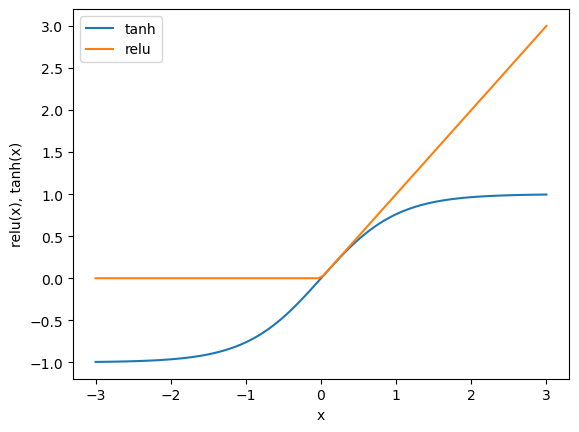

In [4]:
line = np.linspace(-3, 3, 100)
plt.plot(line, np.tanh(line), label="tanh")
plt.plot(line, np.maximum(line, 0), label="relu")
plt.legend(loc="best")
plt.xlabel("x")
plt.ylabel("relu(x), tanh(x)")

## Aprendizagem profunda (*Deep Learning*)

Um hiperparâmetro importante que precisa ser definido pelo usuário é o **número de nós na camada oculta**. Ele pode ser tão pequeno quanto 10 para conjuntos de dados igualmente pequenos, e tão grande quanto 1.000.000 para dados muito complexos. Isso leva a arquiteturas como a mostrada na Figura a seguir. Ter grandes redes neurais compostas por muitas dessas camadas ocultas é o que inspirou o termo **aprendizagem profunda**.

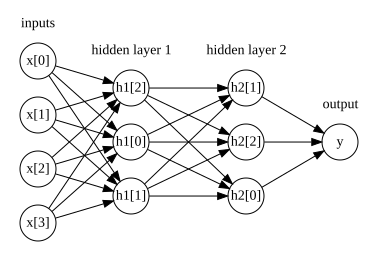

In [5]:
mglearn.plots.plot_two_hidden_layer_graph()

## Configuração das redes neurais para aprendizagem profunda

Vamos observar no funcionamento de um MLP utilizando a classe *MLPClassifier* ao conjunto de dados denominado *two_moons*, que usamos em capítulos anteriores. Os resultados são mostrados na Figura a seguir.

Text(0, 0.5, 'Feature 1')

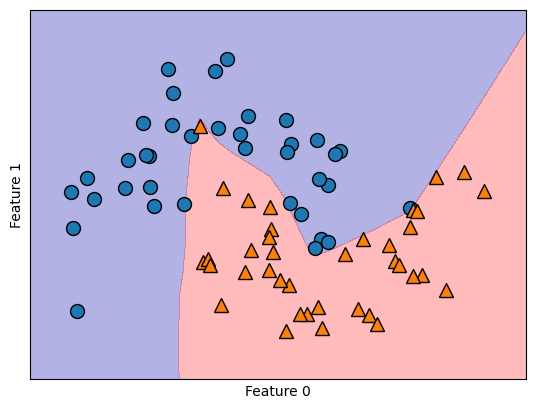

In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=100, noise=0.25, random_state=3)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    random_state=42)

mlp = MLPClassifier(solver='lbfgs', random_state=0).fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Como você pode perceber, a rede neural aprendeu um limite de decisão não linear, mas relativamente suave. Usamos o hiperparâmetro *solver = 'lbfgs'*, que refere-se à função de otimização para atualização dos pesos. Por padrão, o MLP usa 100 camadas ocultas, o que é bastante para este pequeno conjunto de dados. Podemos reduzir o número de camadas para 10 (o que reduz a complexidade do modelo) e ainda obter um bom resultado, como mostrado na Figura a seguir.

C:\Users\JEFF\anaconda3\envs\aulas04\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:471: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Text(0, 0.5, 'Feature 1')

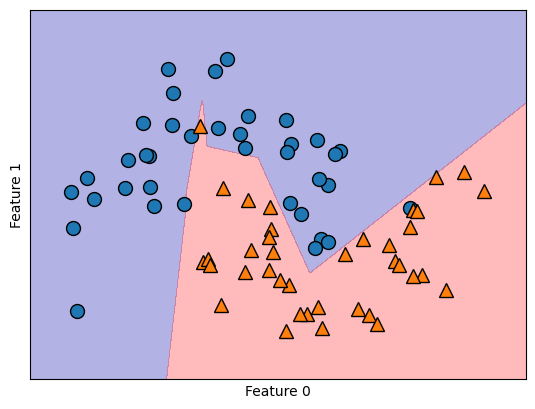

In [7]:
mlp = MLPClassifier(solver='lbfgs', random_state=0, hidden_layer_sizes=[10])
mlp.fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Se quisermos um limite de decisão mais suave, podemos adicionar uma segunda camada oculta, com 10 nós cada uma, como na Figura a seguir.

Text(0, 0.5, 'Feature 1')

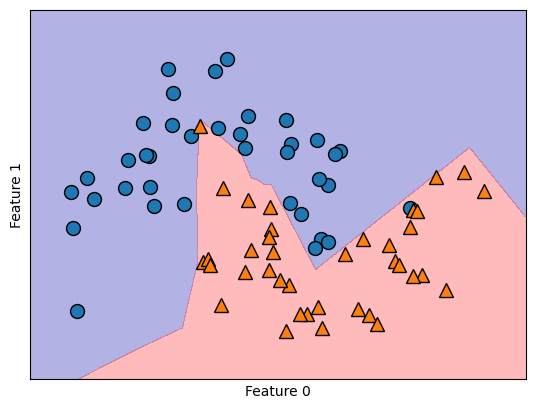

In [8]:
# Usando duas camadas ocultas, com 10 nós cada uma
mlp = MLPClassifier(solver='lbfgs', random_state=0,
                    hidden_layer_sizes=[10, 10])
mlp.fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Podemos ainda usar como função de ativação a função não linear da tangente hiperbólica.

C:\Users\JEFF\anaconda3\envs\aulas04\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:471: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Text(0, 0.5, 'Feature 1')

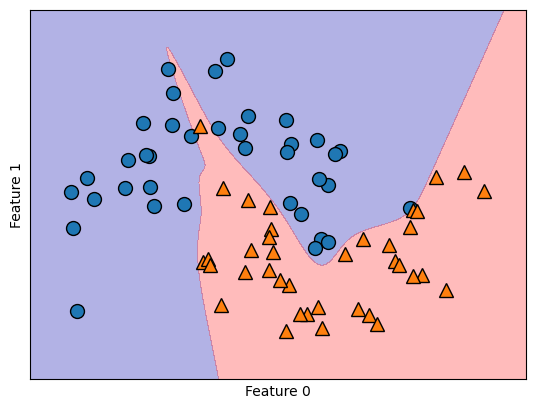

In [9]:
mlp = MLPClassifier(solver='lbfgs', activation='tanh',
                    random_state=0, hidden_layer_sizes=[10, 10])
mlp.fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Nós também podemos controlar a complexidade de uma rede neural usando uma penalidade para reduzir os pesos até zero, como fizemos em um capítulo anterior com os classificadores lineares. O parâmetro que controla essa estraegia na classe *MLPClassifier* é chamado de **alfa** (como nos modelos de regressão linear) e é definido como um valor muito baixo (pouca regularização) por padrão. A Figura a seguir mostra o efeito de diferentes valores de alfa no conjunto de dados *two_moons*, usando duas camadas ocultas de 10 ou 100 nós cada.

C:\Users\JEFF\anaconda3\envs\aulas04\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:471: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\JEFF\anaconda3\envs\aulas04\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:471: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


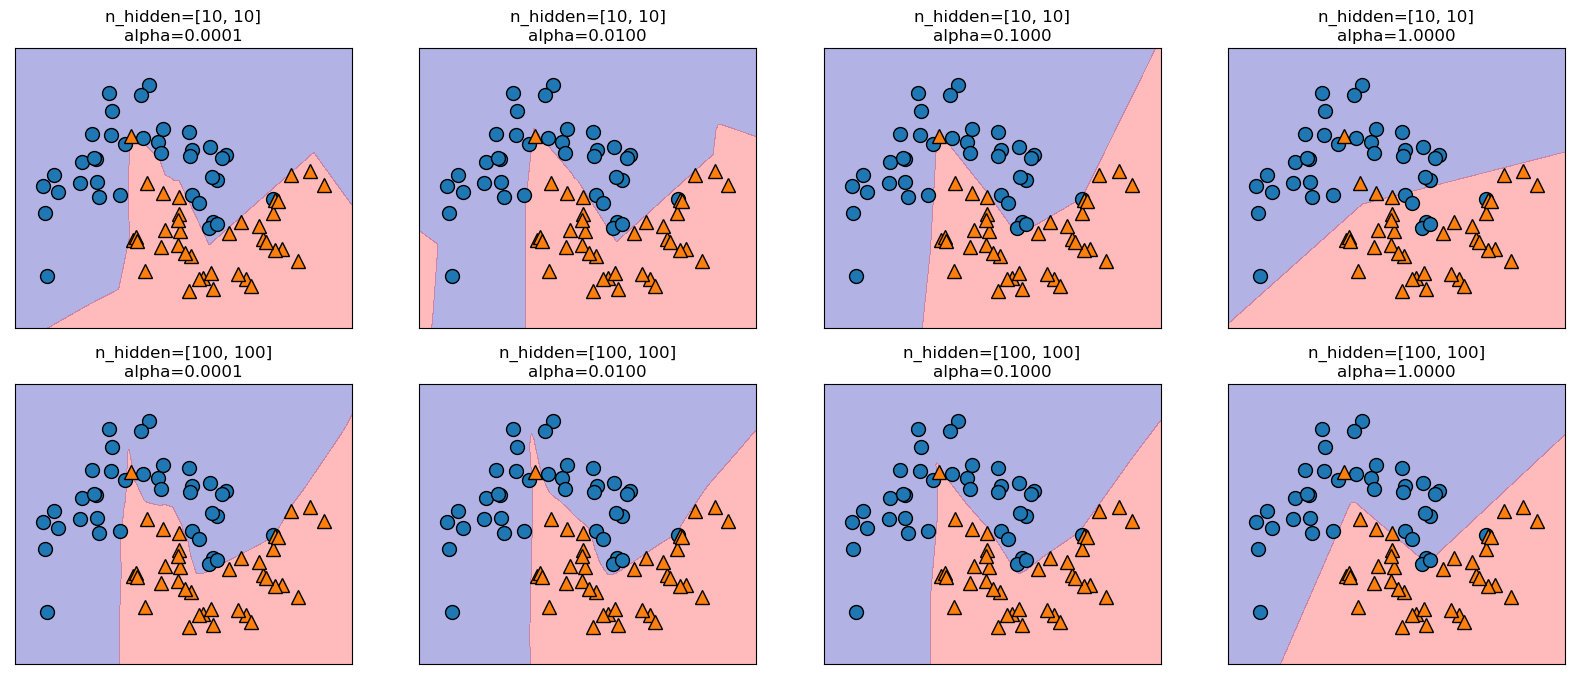

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for axx, n_hidden_nodes in zip(axes, [10, 100]):
    for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
        mlp = MLPClassifier(solver='lbfgs', random_state=0,
                            hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes],
                            alpha=alpha)
        mlp.fit(X_train, y_train)
        mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3, ax=ax)
        mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=ax)
        ax.set_title("n_hidden=[{}, {}]\nalpha={:.4f}".format(
                      n_hidden_nodes, n_hidden_nodes, alpha))

Como você já percebeu, há muitas maneiras de controlar a complexidade de uma rede neural: o número de camadas ocultas, o número de nós em cada camada oculta e a regularização (alfa). 

Uma outra propriedade importante das redes neurais é que seus pesos são definidos aleatoriamente antes do treinamento ser iniciado, e essa inicialização aleatória afeta o processo de aprendizagem. Isso significa que, mesmo usando exatamente os mesmos hiperparâmetros, podemos obter modelos muito diferentes ao usar **sementes (seeds)** aleatórias diferentes. 

Se a arquitetura da rede neural for grande e sua complexidade for escolhida corretamente, isso provavelmente não irá afetar a precisão do modelo, contudo, vale a pena levar em consideração essa característica das redes neurais com arquiteturas menores. A Figura a seguir mostra gráficos de diferentes modelos, todos aprendidos com as mesmas configurações dos parâmetros.

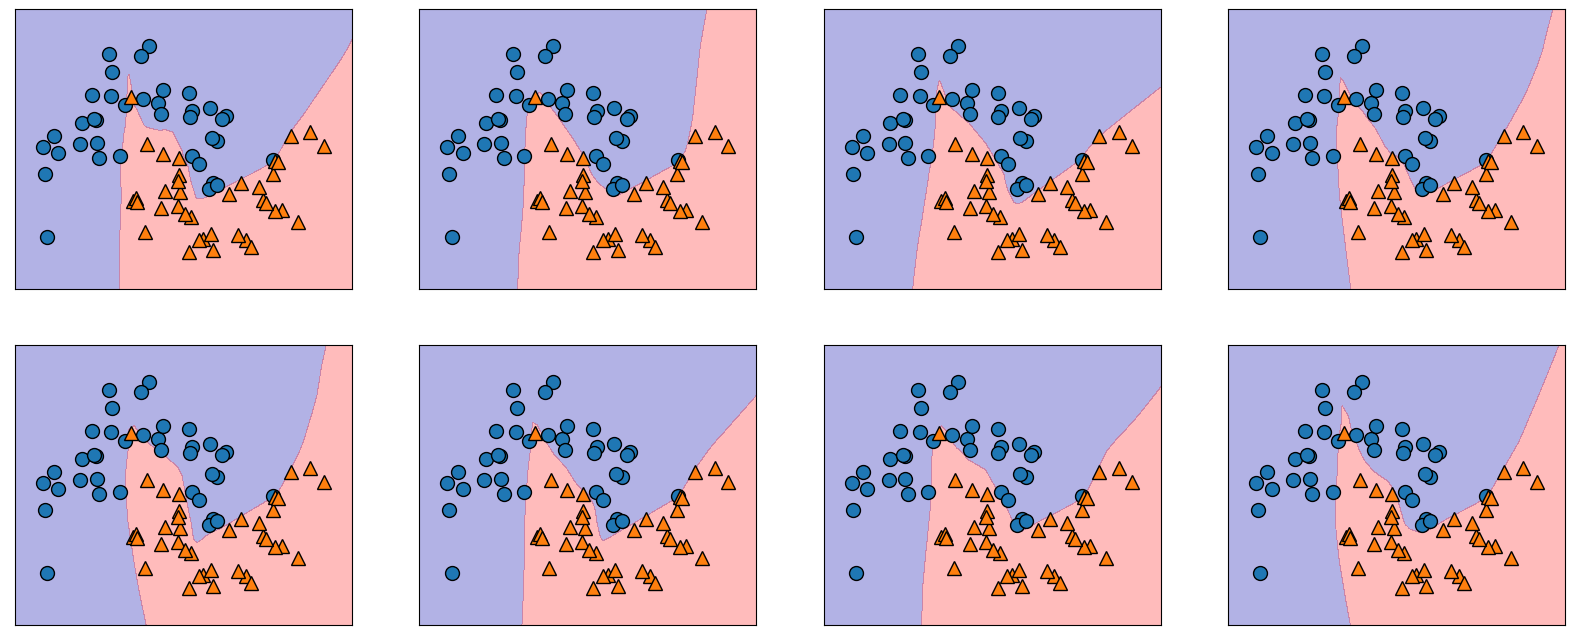

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, ax in enumerate(axes.ravel()):
    mlp = MLPClassifier(solver='lbfgs', random_state=i,
                        hidden_layer_sizes=[100, 100])
    mlp.fit(X_train, y_train)
    mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3, ax=ax)
    mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=ax)

Para uma melhor compreensão das redes neurais em dados do mundo real, vamos aplicar o classificador *MLPClassifier* ao conjunto de dados do câncer de mama. Começamos com os parâmetros padrão, mostrados a seguir.

In [13]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)

print("Acurácia do conjunto de treinamento: {:.2f}".format(mlp.score(X_train, y_train)))
print("Acurácia do conjunto de teste: {:.2f}".format(mlp.score(X_test, y_test)))

Acurácia do conjunto de treinamento: 0.94
Acurácia do conjunto de teste: 0.92


A precisão do MLP é muito boa, mas não tão boa quanto a de outros modelos descritos anteriormente. As redes neurais também esperam que todos os atributos de entrada estejam normalizados e variem de maneira semelhante e, idealmente, tenham uma média de 0 e uma variação (desvio padrão) de 1. Devemos redimensionar nossos dados para que atendam a esses requisitos. Para este exemplo, faremos isso manualmente, como mostrado a seguir. 

In [14]:
# calcular o valor da média para cada atributo do conjunto de treinamento
mean_on_train = X_train.mean(axis=0)
# calcular o desvio padrão para cada atributo do conjunto de treinamento
std_on_train = X_train.std(axis=0)

# subtrair a média e dimensionar o valor pelo desvio padrão inverso
# depois disso, média=0 and desvio padrão=1
X_train_scaled = (X_train - mean_on_train) / std_on_train
# usar A MESMA transformação nos dados de teste
X_test_scaled = (X_test - mean_on_train) / std_on_train

mlp = MLPClassifier(random_state=0)
mlp.fit(X_train_scaled, y_train)

print("Acurácia do conjunto de treinamento: {:.3f}".format(
    mlp.score(X_train_scaled, y_train)))
print("Acurácia do conjunto de teste: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

Acurácia do conjunto de treinamento: 0.991
Acurácia do conjunto de teste: 0.965


C:\Users\JEFF\anaconda3\envs\teste01\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Os resultados são  melhores após o redimensionamento dos atributos. Porém, recebemos um aviso do modelo que nos informa que o número **máximo de iterações** foi atingido. Esse aviso faz parte do algoritmo, e nos alerta que para ter um melhor desempenho devemos aumentar o número de iterações, por meio do hiperparâmetro *max_iter*. Observe no exemplo a seguir que o desempenho do MLP foi superior ao do exemplo anterior.

In [15]:
mlp = MLPClassifier(max_iter=1000, random_state=0)
mlp.fit(X_train_scaled, y_train)

print("Acurácia do conjunto de treinamento: {:.3f}".format(
    mlp.score(X_train_scaled, y_train)))
print("Acurácia do conjunto de teste: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

Acurácia do conjunto de treinamento: 1.000
Acurácia do conjunto de teste: 0.972


Aumentar o número de iterações aumentou o desempenho do conjunto de treinamento, mas foi pouco efetivo no desempenho de generalização. Ainda assim, o modelo está funcionando bem. Como há alguma lacuna entre o treinamento e o desempenho do teste, podemos tentar diminuir a complexidade do modelo para para analisar o efeito no desempenho de generalização. Aqui, optamos por aumentar o parâmetro *alfa* (de forma bastante agressiva, de 0.0001 para 1) para adicionar uma regularização mais forte dos pesos.

In [16]:
mlp = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp.fit(X_train_scaled, y_train)

print("Acurácia do conjunto de treinamento: {:.3f}".format(
    mlp.score(X_train_scaled, y_train)))
print("Acurácia do conjunto de teste: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

Acurácia do conjunto de treinamento: 0.988
Acurácia do conjunto de teste: 0.972


Embora seja possível analisar o que uma rede neural aprendeu, isso geralmente é muito mais complicado do que analisar um modelo linear ou um modelo baseado em árvore de decisão. Uma maneira de introspectar o que foi aprendido é examinar os pesos no modelo. 

Você pode ver um exemplo disso na galeria de exemplos da biblioteca scikit-learn. Para o conjunto de dados do câncer de mama, esse entendimento é um pouco mais complexo. O gráfico a seguir mostra os pesos que foram aprendidos conectando a entrada à primeira camada oculta. 

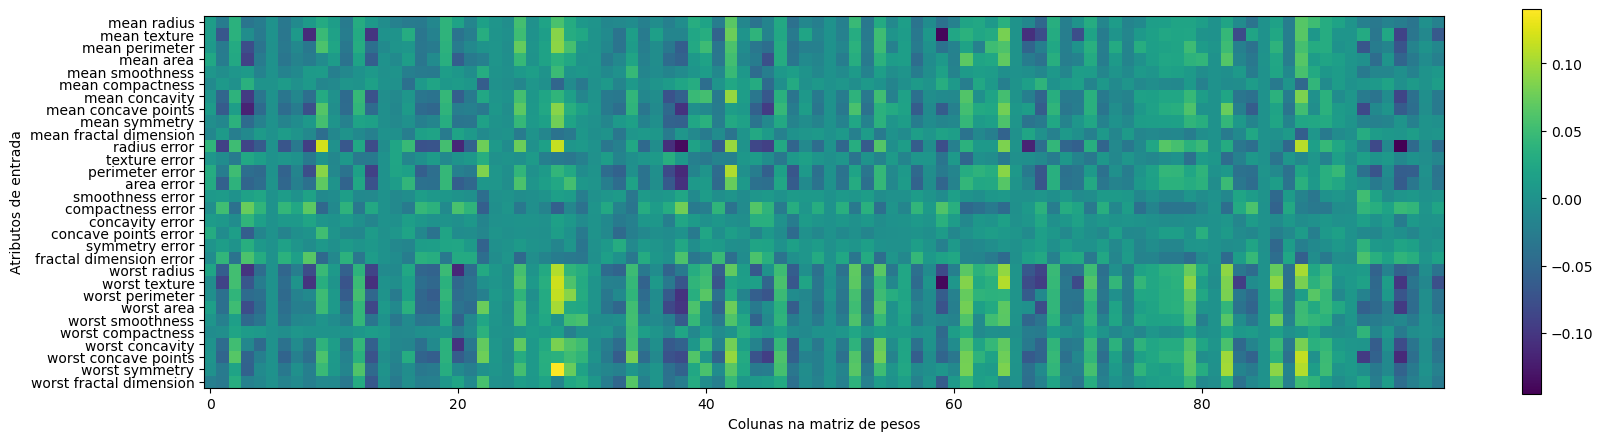

In [17]:
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel("Colunas na matriz de pesos")
plt.ylabel("Atributos de entrada")
plt.colorbar()

As linhas neste gráfico correspondem aos 30 atributos de entrada, enquanto as colunas correspondem às 100 camadas ocultas. As cores claras representam grandes valores positivos, enquanto as cores escuras representam valores negativos.

Uma possível inferência que podemos fazer é que os atributos com pesos muito pequenos para todas as camadas ocultas são "menos importantes" para o modelo. Podemos ver que *mean smoothness* e *mean compactness*, além dos atributos encontrados entre *smoothness error* e *fractal dimension error*, têm pesos relativamente baixos em comparação com outros atributos. Isso pode significar que esses são atributos menos importantes, ou talvez não os tenhamos representamos de uma forma que a rede neural possa usar eficientemente.